## Instalação de pacotes

In [ ]:
# Não execute se já instalados
!pip install scikit-learn pandas numpy matplotlib seaborn graphviz

## Pacotes e Carregamento do Dataset

In [ ]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV

# Configuração de visualização
%matplotlib inline
sns.set_style("whitegrid")

# Carregar o dataset
df = pd.read_csv('column_2C.csv')

# Visualização inicial
print("Dimensões:", df.shape)
print("Classes:\n", df['class'].value_counts())
df.head()

Dimensões: (310, 7)
Classes:
 class
Abnormal    210
Normal      100
Name: count, dtype: int64


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


## Análise Exploratória

Estatísticas descritivas:


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767933
75%,72.877696,22.120395,63.000000,52.695889,125.467675,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082



Valores ausentes por coluna:
pelvic_incidence            0
pelvic_tilt                 0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
class                       0
dtype: int64


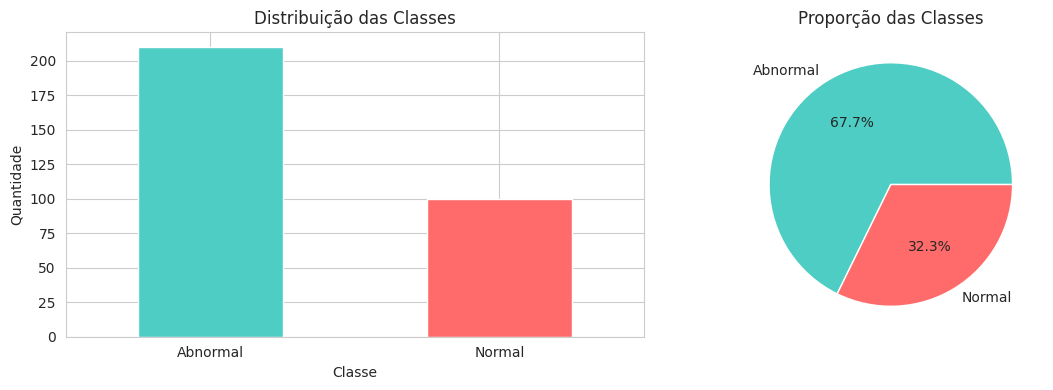

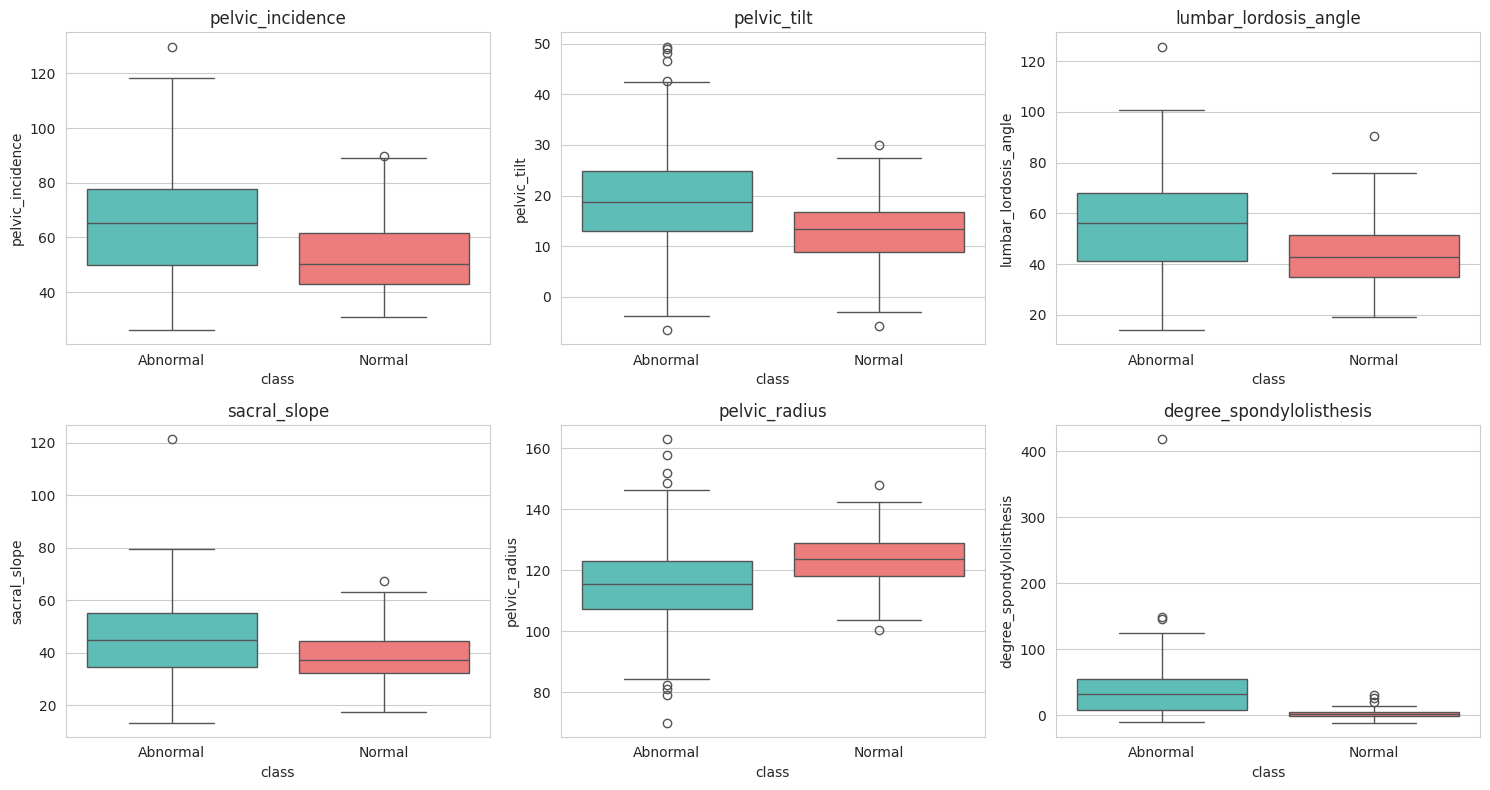

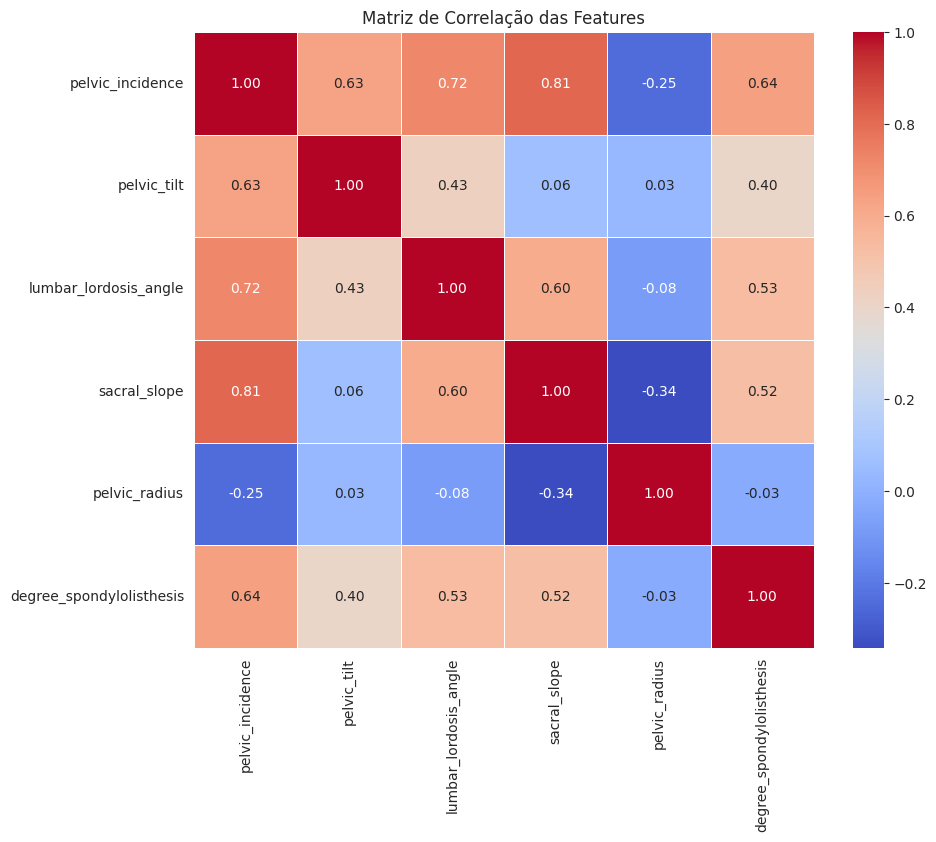

In [ ]:
print("Estatísticas descritivas:")
display(df.describe())

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

# Distribuição das classes
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
df['class'].value_counts().plot(kind='bar', color=['#4ECDC4', '#FF6B6B'])
plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)

plt.subplot(1,2,2)
df['class'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#4ECDC4', '#FF6B6B'])
plt.title('Proporção das Classes')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Boxplots das features por classe
features = df.columns[:-1]  # todas exceto 'class'
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(x='class', y=col, data=df, ax=axes[i],
                hue='class', palette=['#4ECDC4', '#FF6B6B'], legend=False)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# Matriz de correlação
plt.figure(figsize=(10,8))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação das Features')
plt.show()

## Pré-processamento e Normalização

In [ ]:
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Treino: {X_train_scaled.shape[0]} amostras")
print(f"Teste: {X_test_scaled.shape[0]} amostras")

Treino: 217 amostras
Teste: 93 amostras


## Otimização de hiperparâmetros e treinamento

### 1. Naive Bayes



In [ ]:
print("Otimização do Naive Bayes")
param_nb = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
grid_nb = GridSearchCV(GaussianNB(), param_nb, cv=5, scoring='accuracy', n_jobs=-1)
grid_nb.fit(X_train_scaled, y_train)

model_nb = grid_nb.best_estimator_
print(f"Melhor var_smoothing: {grid_nb.best_params_['var_smoothing']:.0e}")
print(f"Acurácia (validação cruzada): {grid_nb.best_score_:.2%}")

y_pred_nb = model_nb.predict(X_test_scaled)
acuracia_nb = accuracy_score(y_test, y_pred_nb)
print(f"Acurácia no teste: {acuracia_nb:.2%}")

y_proba_nb = model_nb.predict_proba(X_test_scaled)
print("\nProbabilidades (primeiras 5 amostras):")
for i in range(min(5, len(X_test_scaled))):
    prob_normal = y_proba_nb[i][1] * 100
    prob_abnormal = y_proba_nb[i][0] * 100
    print(f"Amostra {i+1}: Normal={prob_normal:.2f}%, Abnormal={prob_abnormal:.2f}% | Real: {y_test.iloc[i]}")

Otimização do Naive Bayes
Melhor var_smoothing: 1e-09
Acurácia (validação cruzada): 77.89%
Acurácia no teste: 78.49%

Probabilidades (primeiras 5 amostras):
Amostra 1: Normal=1.64%, Abnormal=98.36% | Real: Abnormal
Amostra 2: Normal=92.66%, Abnormal=7.34% | Real: Abnormal
Amostra 3: Normal=0.00%, Abnormal=100.00% | Real: Abnormal
Amostra 4: Normal=97.88%, Abnormal=2.12% | Real: Abnormal
Amostra 5: Normal=0.00%, Abnormal=100.00% | Real: Abnormal


### 2. Árvore de Decisão

In [ ]:
print("Otimização da Árvore de Decisão")
param_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 3],
    'criterion': ['gini', 'entropy']
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train_scaled, y_train)

model_dt = grid_dt.best_estimator_
print(f"Melhores parâmetros: {grid_dt.best_params_}")
print(f"Acurácia (validação cruzada): {grid_dt.best_score_:.2%}")

y_pred_dt = model_dt.predict(X_test_scaled)
acuracia_dt = accuracy_score(y_test, y_pred_dt)
print(f"Acurácia no teste: {acuracia_dt:.2%}")

y_proba_dt = model_dt.predict_proba(X_test_scaled)
print("\nProbabilidades (primeiras 5 amostras):")
for i in range(min(5, len(X_test_scaled))):
    prob_normal = y_proba_dt[i][1] * 100
    prob_abnormal = y_proba_dt[i][0] * 100
    print(f"Amostra {i+1}: Normal={prob_normal:.2f}%, Abnormal={prob_abnormal:.2f}% | Real: {y_test.iloc[i]}")

Otimização da Árvore de Decisão
Melhores parâmetros: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2}
Acurácia (validação cruzada): 82.53%
Acurácia no teste: 82.80%

Probabilidades (primeiras 5 amostras):
Amostra 1: Normal=8.33%, Abnormal=91.67% | Real: Abnormal
Amostra 2: Normal=33.33%, Abnormal=66.67% | Real: Abnormal
Amostra 3: Normal=0.00%, Abnormal=100.00% | Real: Abnormal
Amostra 4: Normal=33.33%, Abnormal=66.67% | Real: Abnormal
Amostra 5: Normal=0.00%, Abnormal=100.00% | Real: Abnormal


#### Visualização

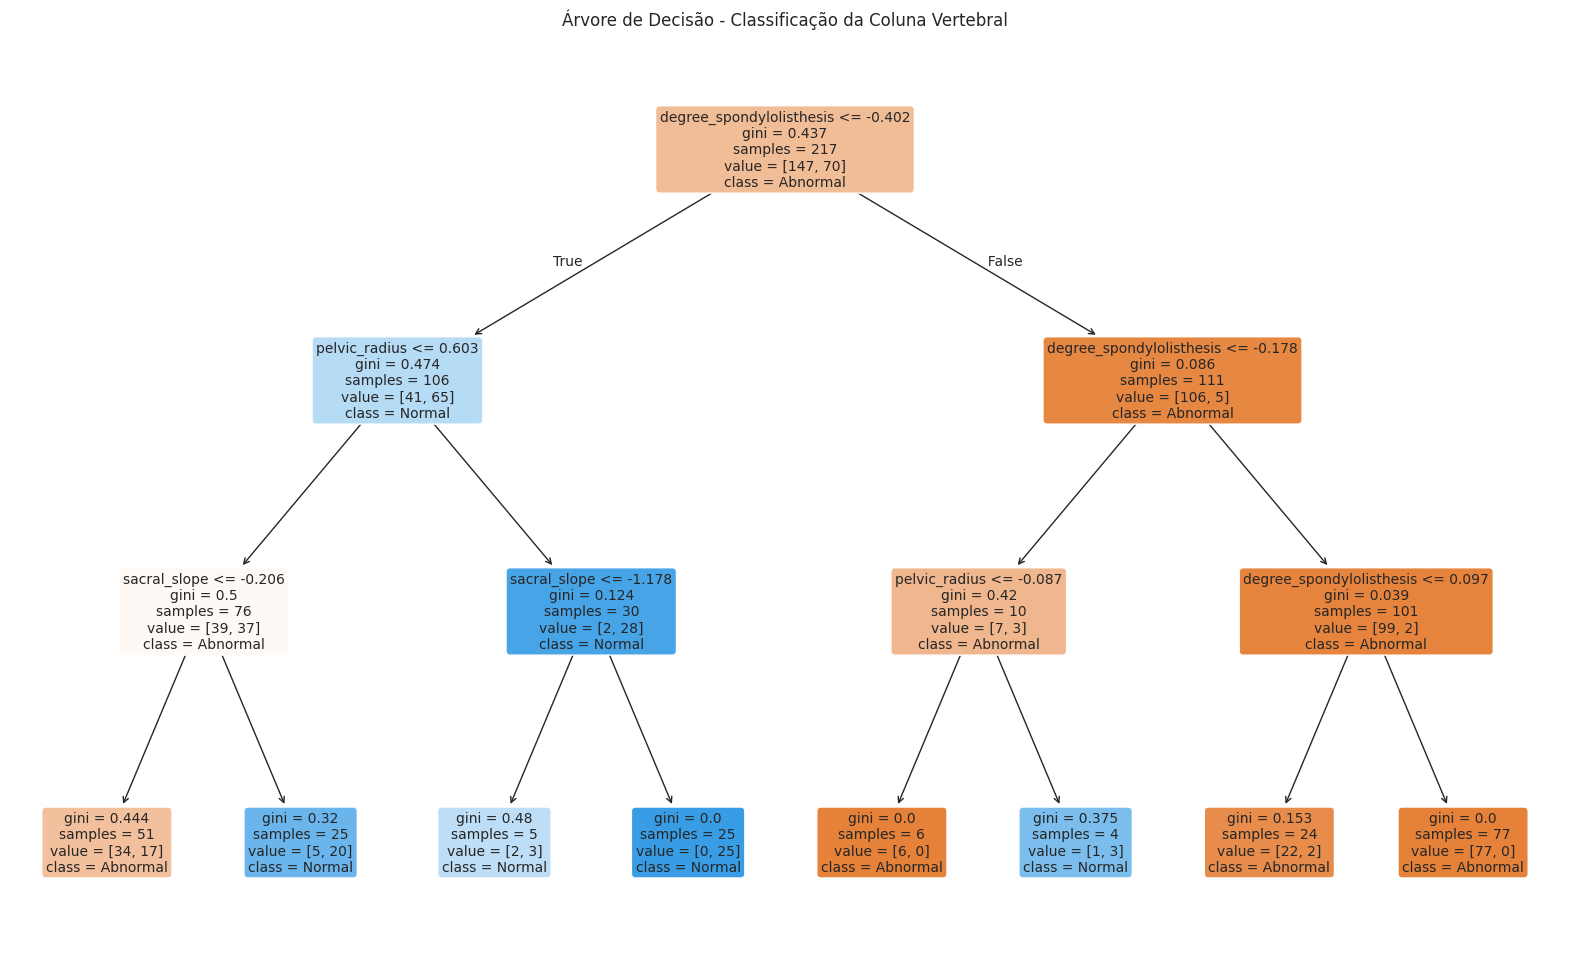

In [ ]:
plt.figure(figsize=(20, 12))
plot_tree(model_dt,
          feature_names=X.columns,
          class_names=['Abnormal', 'Normal'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árvore de Decisão - Classificação da Coluna Vertebral')
plt.show()

### 3. K-NN

In [ ]:
print("Otimização do KNN")
param_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)

model_knn = grid_knn.best_estimator_
print(f"Melhores parâmetros: {grid_knn.best_params_}")
print(f"Acurácia (validação cruzada): {grid_knn.best_score_:.2%}")

# Avaliação no teste
y_pred_knn = model_knn.predict(X_test_scaled)
acuracia_knn = accuracy_score(y_test, y_pred_knn)
print(f"Acurácia no teste: {acuracia_knn:.2%}")

# Probabilidades das primeiras amostras de teste
y_proba_knn = model_knn.predict_proba(X_test_scaled)
print("\nProbabilidades (primeiras 5 amostras):")
print("Classe 0: Abnormal, Classe 1: Normal")
for i in range(min(5, len(X_test_scaled))):
    prob_normal = y_proba_knn[i][1] * 100
    prob_abnormal = y_proba_knn[i][0] * 100
    print(f"Amostra {i+1}: Normal={prob_normal:.2f}%, Abnormal={prob_abnormal:.2f}% | Real: {y_test.iloc[i]}")

Acurácia do KNN: 80.65%


#### Visualização

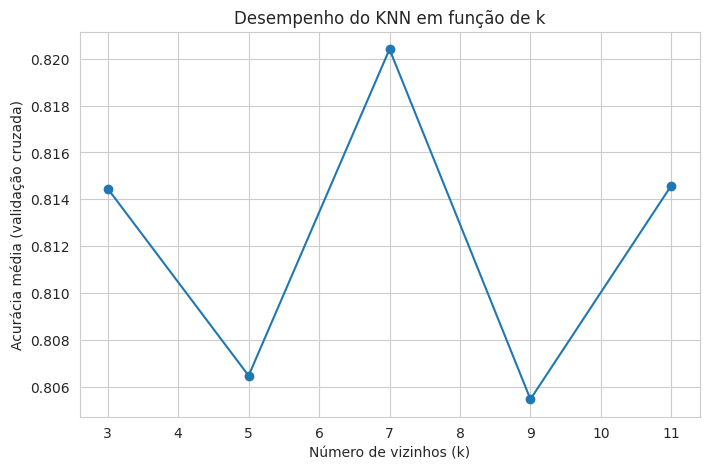

In [ ]:
k_values = param_knn['n_neighbors']
scores_k = []
for k in k_values:
    mask = grid_knn.cv_results_['param_n_neighbors'] == k
    mean_score = grid_knn.cv_results_['mean_test_score'][mask].mean()
    scores_k.append(mean_score)

plt.figure(figsize=(8,5))
plt.plot(k_values, scores_k, marker='o')
plt.xlabel('Número de vizinhos (k)')
plt.ylabel('Acurácia média (validação cruzada)')
plt.title('Desempenho do KNN em função de k')
plt.grid(True)
plt.show()

## 4. Comparação de Desempenho

Comparação de Acurácia:


,Modelo,Acurácia
0,Naive Bayes,0.784946
1,Árvore de Decisão,0.827957
2,KNN,0.795699


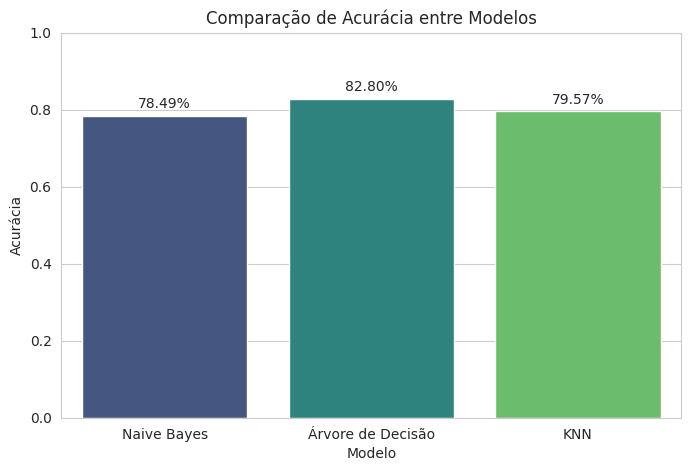

In [49]:
resultados = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'Árvore de Decisão', 'KNN'],
    'Acurácia': [acuracia_nb, acuracia_dt, acuracia_knn]
})
print("Comparação de Acurácia:")
display(resultados)

plt.figure(figsize=(8,5))
sns.barplot(x='Modelo', y='Acurácia', data=resultados,
            hue='Modelo', palette='viridis', legend=False)
plt.ylim(0, 1)
plt.title('Comparação de Acurácia entre Modelos')
for i, row in resultados.iterrows():
    plt.text(i, row['Acurácia'] + 0.02, f"{row['Acurácia']:.2%}", ha='center')
plt.show()

## 5. Função de Predição

In [ ]:
def predizer_paciente(dados_paciente, modelo='dt', alpha=0.1):
    """
    Parâmetros:
    - dados_paciente: dicionário com as 6 features
    - modelo: 'nb', 'dt' ou 'knn'
    - alpha: parâmetro de suavização de Laplace (0 = sem suavização, valores > 0 suavizam)
    """
    df_paciente = pd.DataFrame([dados_paciente])
    df_paciente_scaled = scaler.transform(df_paciente)
    df_paciente_scaled = pd.DataFrame(df_paciente_scaled, columns=X.columns)

    if modelo == 'nb':
        prob_raw = model_nb.predict_proba(df_paciente_scaled)[0]
        pred = model_nb.predict(df_paciente_scaled)[0]
        nome_modelo = 'Naive Bayes'
    elif modelo == 'dt':
        prob_raw = model_dt.predict_proba(df_paciente_scaled)[0]
        pred = model_dt.predict(df_paciente_scaled)[0]
        nome_modelo = 'Árvore de Decisão'
    else:
        prob_raw = model_knn.predict_proba(df_paciente_scaled)[0]
        pred = model_knn.predict(df_paciente_scaled)[0]
        nome_modelo = 'KNN'

    # Suavização de Laplace
    prob_suav = (prob_raw + alpha) / (1 + 2 * alpha)

    prob_abnormal = prob_suav[0] * 100
    prob_normal = prob_suav[1] * 100

    print(f"\n{'='*60}")
    print(f"PREDIÇÃO (suavização α={alpha}) - Modelo: {nome_modelo}")
    print('='*60)
    print("Características do paciente:")
    for k, v in dados_paciente.items():
        print(f"  {k}: {v}")
    print("\nProbabilidades suavizadas:")
    print(f"  Normal: {prob_normal:.2f}%")
    print(f"  Abnormal: {prob_abnormal:.2f}%")
    print(f"\nClassificação: {pred}")
    print('='*60)

    return {'predicao': pred,
            'probabilidade_normal': prob_normal,
            'probabilidade_abnormal': prob_abnormal}

## 6. Testes com novos pacientes (dados sintéticos)

In [ ]:
novos_pacientes = [
    {'pelvic_incidence': 60.0, 'pelvic_tilt': 20.0, 'lumbar_lordosis_angle': 45.0,
     'sacral_slope': 40.0, 'pelvic_radius': 110.0, 'degree_spondylolisthesis': 5.0},
    {'pelvic_incidence': 35.0, 'pelvic_tilt': 5.0, 'lumbar_lordosis_angle': 30.0,
     'sacral_slope': 25.0, 'pelvic_radius': 125.0, 'degree_spondylolisthesis': -2.0},
    {'pelvic_incidence': 80.0, 'pelvic_tilt': 30.0, 'lumbar_lordosis_angle': 70.0,
     'sacral_slope': 50.0, 'pelvic_radius': 100.0, 'degree_spondylolisthesis': 60.0}
]

for i, paciente in enumerate(novos_pacientes, 1):
    print(f"\n--- Teste {i} ---")
    predizer_paciente(paciente, modelo='dt')


--- Teste 1 ---

PREDIÇÃO (suavização α=0.1) - Modelo: Árvore de Decisão
Características do paciente:
  pelvic_incidence: 60.0
  pelvic_tilt: 20.0
  lumbar_lordosis_angle: 45.0
  sacral_slope: 40.0
  pelvic_radius: 110.0
  degree_spondylolisthesis: 5.0

Probabilidades suavizadas:
  Normal: 36.11%
  Abnormal: 63.89%

Classificação: Abnormal

--- Teste 2 ---

PREDIÇÃO (suavização α=0.1) - Modelo: Árvore de Decisão
Características do paciente:
  pelvic_incidence: 35.0
  pelvic_tilt: 5.0
  lumbar_lordosis_angle: 30.0
  sacral_slope: 25.0
  pelvic_radius: 125.0
  degree_spondylolisthesis: -2.0

Probabilidades suavizadas:
  Normal: 36.11%
  Abnormal: 63.89%

Classificação: Abnormal

--- Teste 3 ---

PREDIÇÃO (suavização α=0.1) - Modelo: Árvore de Decisão
Características do paciente:
  pelvic_incidence: 80.0
  pelvic_tilt: 30.0
  lumbar_lordosis_angle: 70.0
  sacral_slope: 50.0
  pelvic_radius: 100.0
  degree_spondylolisthesis: 60.0

Probabilidades suavizadas:
  Normal: 8.33%
  Abnormal: 91.

## 7. Relatório e Matriz de Confusão

Relatório de Classificação - Árvore de Decisão
              precision    recall  f1-score   support

      Normal       0.85      0.90      0.88        63
    Abnormal       0.77      0.67      0.71        30

    accuracy                           0.83        93
   macro avg       0.81      0.79      0.80        93
weighted avg       0.82      0.83      0.82        93



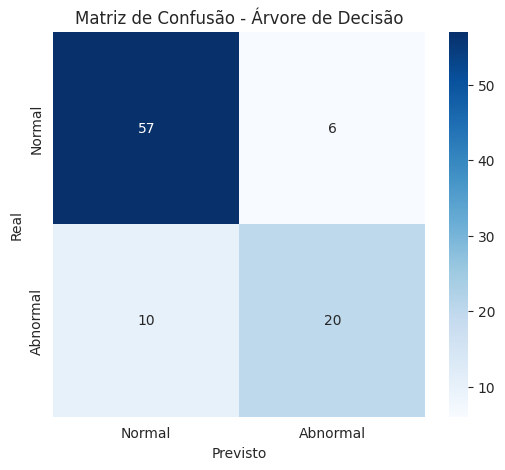

In [ ]:
print("Relatório de Classificação - Árvore de Decisão")
print(classification_report(y_test, y_pred_dt, target_names=['Normal', 'Abnormal']))

cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()